In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")
from src import *

/home/vmorelli-iit.local/Projects/freq2clean/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cupy Available= 1


In [13]:
SELECTED_TRAINING = "20251118-1221-synthetic_deepcad_150" # "20251118-1205-synthetic_deepcad_15"
USE_VARIANT_085 = False
DATASET_NAME: str | None = "mouse_neuronal_populations" # synthetic
DENOISER_VARIANT: str | None = "_150"
GT_VARIANT: str | None = None
AVG_WIN: int | None = None
MAX_FRAMES=1000

In [15]:
# 10s
cfg = json.load(open(f"trainings/{SELECTED_TRAINING}/cfg.json"))
dataset_name = DATASET_NAME or cfg["dataset_name"]
variant = DENOISER_VARIANT or cfg["denoiser_variant"]
training_dir = Path(f"results/{dataset_name}/{cfg["denoiser_name"]}{variant}{AVG_WIN or ''}")
metrics_path = Path(training_dir / "metrics.json")
metrics = json.load(metrics_path.open())

deepcad = Recording(
    f"dataset/{dataset_name}/{cfg["denoiser_name"]}{variant}.tif",
    max_frames=MAX_FRAMES,
)
f2c_grid = Recording(
    training_dir / "grid.tiff",
    max_frames=MAX_FRAMES,
)
f2c_net = Recording(
    training_dir / f"{SELECTED_TRAINING}{'_0.85' if USE_VARIANT_085 else ''}.tiff",
    max_frames=MAX_FRAMES,
)
gt = Recording(
    f"dataset/{dataset_name}/gt{GT_VARIANT or ''}.tif",
    max_frames=MAX_FRAMES,
)

In [5]:
deepcad = deepcad.normalized
gt = gt.normalized
f2c_grid = np.clip(f2c_grid.np, 0, 1)
f2c_net = np.clip(f2c_net.np, 0, 1)

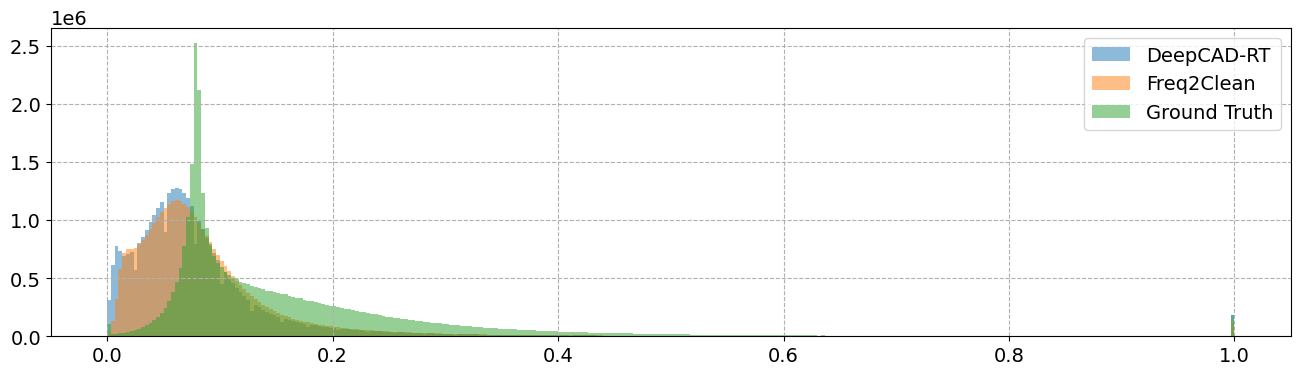

In [6]:
ax = pd.Series(deepcad.flatten()[::4]).hist(bins=300, alpha=0.5, figsize=(16, 4), label="DeepCAD-RT")
pd.Series(f2c_net.flatten()[::4]).hist(bins=300, alpha=0.5, ax=ax, label="Freq2Clean")
pd.Series(gt.flatten()[::4]).hist(bins=300, alpha=0.5, ax=ax, label="Ground Truth")
plt.legend();

The distribution is aligned, no need to *normalize* `f2c_grid` and `f2c_net`.

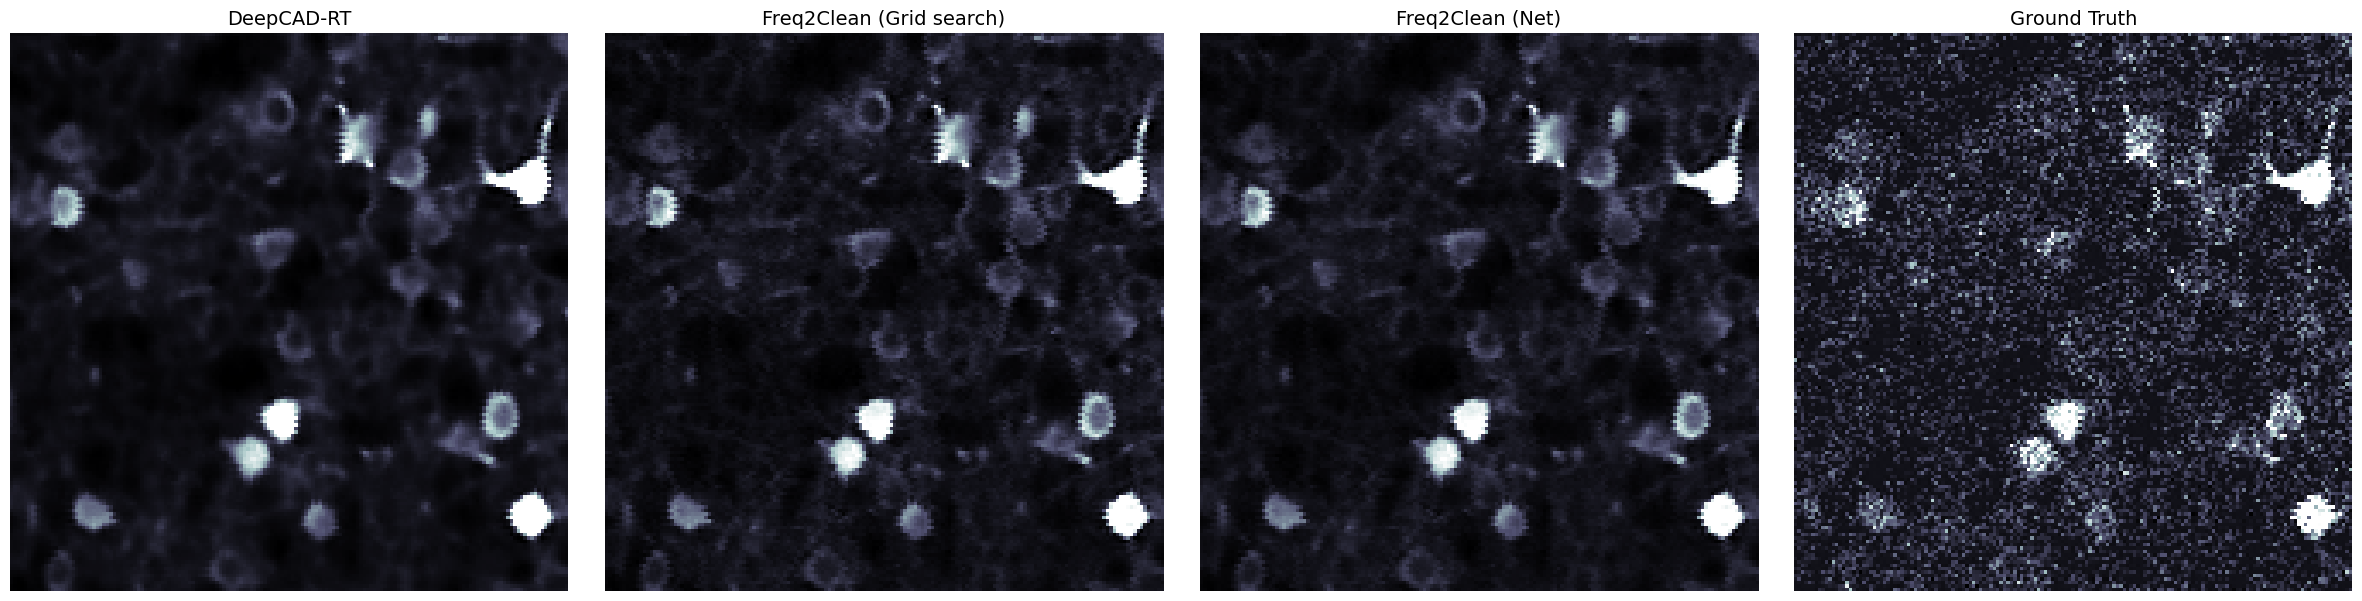

In [7]:
frame = random.randrange(gt.shape[0])
imshow(
    {
        "DeepCAD-RT": deepcad[frame],
        "Freq2Clean (Grid search)": f2c_grid[frame],
        "Freq2Clean (Net)": f2c_net[frame],
        "Ground Truth": gt[frame],
    },
    size=6,
    cmap="bone",
    zoom=3,
    vrange=(0,1)
)

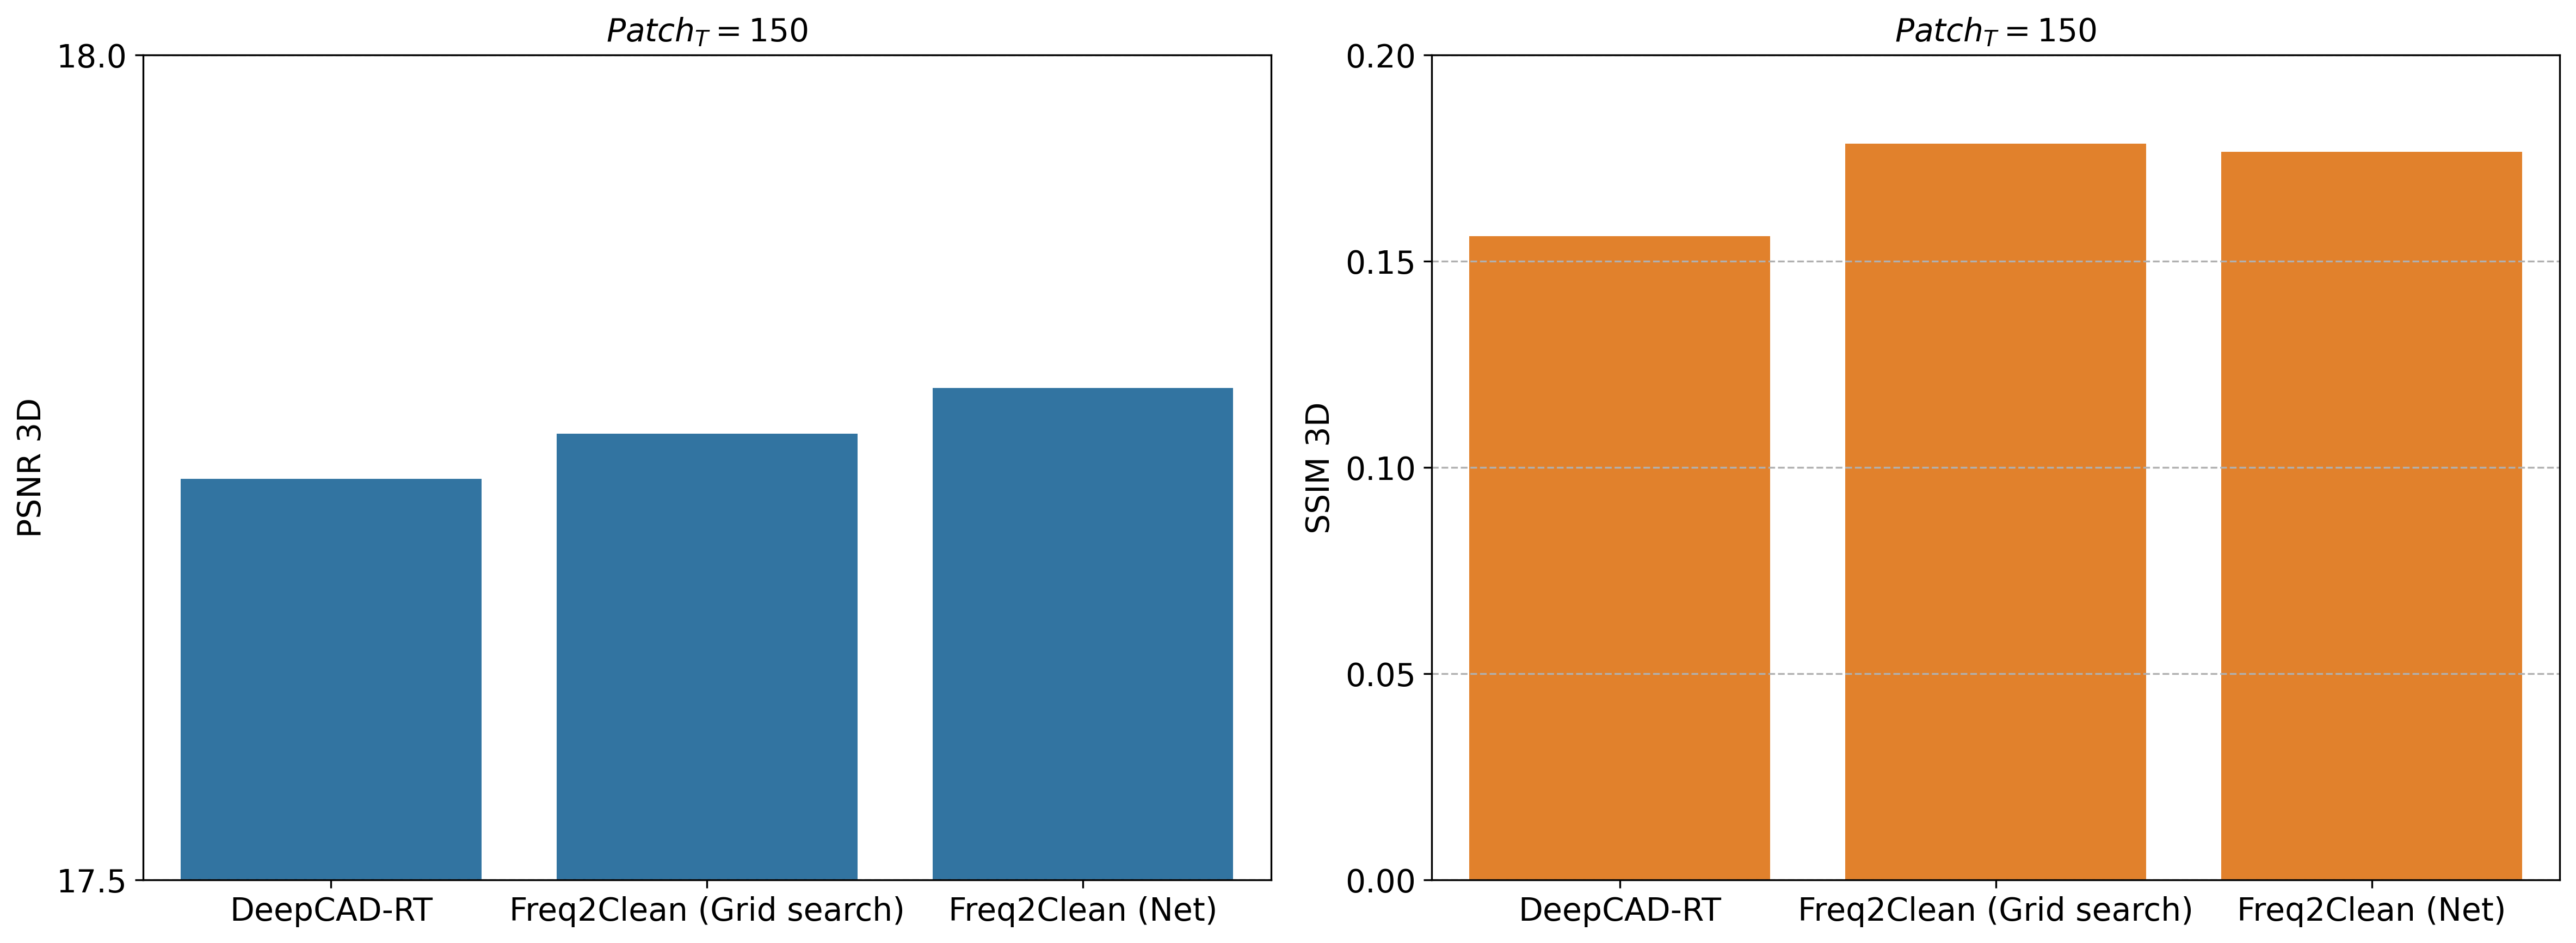

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
barchart(
    {
        "DeepCAD-RT": metrics["deepcad"]["psnr3d"],
        "Freq2Clean (Grid search)": metrics["grid"]["psnr3d"],
        "Freq2Clean (Net)": metrics[SELECTED_TRAINING]["psnr3d"],
    },
    bounds=(17.5, 18),
    yaxis="PSNR 3D",
    ysteps=1,
    color="tab:blue",
    title=f"$Patch_T={variant[1:]}$",
    ax=axs[0],
)
barchart(
    {
        "DeepCAD-RT": metrics["deepcad"]["ssim3d"],
        "Freq2Clean (Grid search)": metrics["grid"]["ssim3d"],
        "Freq2Clean (Net)": metrics[SELECTED_TRAINING]["ssim3d"],
    },
    bounds=(0.0, 0.2),
    yaxis="SSIM 3D",
    ysteps=4,
    color="tab:orange",
    title=f"$Patch_T={variant[1:]}$",
    ax=axs[1],
)

The Freq2Clean(net) generalizes *quite* good. When I use the variant `150` on the dataset `15` and viceversa, it performs *slightly* worse than the version trainined for the same dataset.